# Autocomplete and Autocorrect Data Analytics

## Objective

The objective of this project is to analyse and implement autocomplete
and autocorrect techniques using Natural Language Processing (NLP).

The project includes:

- Text corpus preprocessing
- Frequency-based n-gram autocomplete
- Bigram and trigram prediction
- Edit-distance based autocorrect
- Evaluation of autocomplete and autocorrect
- Comparison of different approaches
- Data visualisation and analysis

## Technologies Used

- Python
- Pandas
- NumPy
- NLTK
- Matplotlib
- PySpellChecker
- Jupyter Notebook

In [5]:
import sys

print("Python version:", sys.version)

Python version: 3.11.5 (tags/v3.11.5:cce6ba9, Aug 24 2023, 14:38:34) [MSC v.1936 64 bit (AMD64)]


In [7]:
!pip install pandas nltk pyspellchecker textdistance matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
!pip install nltk


[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import nltk

print("NLTK is working!")

NLTK is working!


In [18]:
%pip install pyspellchecker

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter, defaultdict
from nltk.corpus import gutenberg, stopwords
from spellchecker import SpellChecker

print("Libraries imported successfully!")

Libraries imported successfully!


In [10]:
nltk.download('gutenberg')
nltk.download('stopwords')

[nltk_data] Downloading package gutenberg to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [11]:
from nltk.corpus import gutenberg

print("Available Gutenberg files:")
print(gutenberg.fileids())

Available Gutenberg files:
['austen-emma.txt', 'austen-persuasion.txt', 'austen-sense.txt', 'bible-kjv.txt', 'blake-poems.txt', 'bryant-stories.txt', 'burgess-busterbrown.txt', 'carroll-alice.txt', 'chesterton-ball.txt', 'chesterton-brown.txt', 'chesterton-thursday.txt', 'edgeworth-parents.txt', 'melville-moby_dick.txt', 'milton-paradise.txt', 'shakespeare-caesar.txt', 'shakespeare-hamlet.txt', 'shakespeare-macbeth.txt', 'whitman-leaves.txt']


In [12]:
print(gutenberg.fileids())

['austen-emma.txt', 'austen-persuasion.txt', 'austen-sense.txt', 'bible-kjv.txt', 'blake-poems.txt', 'bryant-stories.txt', 'burgess-busterbrown.txt', 'carroll-alice.txt', 'chesterton-ball.txt', 'chesterton-brown.txt', 'chesterton-thursday.txt', 'edgeworth-parents.txt', 'melville-moby_dick.txt', 'milton-paradise.txt', 'shakespeare-caesar.txt', 'shakespeare-hamlet.txt', 'shakespeare-macbeth.txt', 'whitman-leaves.txt']


In [13]:
import nltk
from nltk.corpus import gutenberg

# Load text from Gutenberg corpus
text = gutenberg.raw('austen-emma.txt')

print("Total characters:", len(text))
print("\nFirst 500 characters:\n")
print(text[:500])

Total characters: 887071

First 500 characters:

[Emma by Jane Austen 1816]

VOLUME I

CHAPTER I


Emma Woodhouse, handsome, clever, and rich, with a comfortable home
and happy disposition, seemed to unite some of the best blessings
of existence; and had lived nearly twenty-one years in the world
with very little to distress or vex her.

She was the youngest of the two daughters of a most affectionate,
indulgent father; and had, in consequence of her sister's marriage,
been mistress of his house from a very early period.  Her mother
had died t


In [14]:
import nltk
from nltk.corpus import gutenberg

# Load text from Gutenberg corpus
text = gutenberg.raw('austen-emma.txt')

print("Total characters:", len(text))
print("\nFirst 500 characters:\n")
print(text[:500])

Total characters: 887071

First 500 characters:

[Emma by Jane Austen 1816]

VOLUME I

CHAPTER I


Emma Woodhouse, handsome, clever, and rich, with a comfortable home
and happy disposition, seemed to unite some of the best blessings
of existence; and had lived nearly twenty-one years in the world
with very little to distress or vex her.

She was the youngest of the two daughters of a most affectionate,
indulgent father; and had, in consequence of her sister's marriage,
been mistress of his house from a very early period.  Her mother
had died t


In [18]:
# Simple word tokenization without punkt_tab

words = text.split()

print("Total tokens:", len(words))
print("\nFirst 30 tokens:")
print(words[:30])

Total tokens: 158167

First 30 tokens:
['[Emma', 'by', 'Jane', 'Austen', '1816]', 'VOLUME', 'I', 'CHAPTER', 'I', 'Emma', 'Woodhouse,', 'handsome,', 'clever,', 'and', 'rich,', 'with', 'a', 'comfortable', 'home', 'and', 'happy', 'disposition,', 'seemed', 'to', 'unite', 'some', 'of', 'the', 'best', 'blessings']


In [19]:
import string

# Convert all words to lowercase
words_lower = [word.lower() for word in words]

# Keep only alphabetic words
clean_words = [
    word for word in words_lower
    if word.isalpha()
]

print("Total clean words:", len(clean_words))
print("\nFirst 30 clean words:")
print(clean_words[:30])

Total clean words: 128684

First 30 clean words:
['by', 'jane', 'austen', 'volume', 'i', 'chapter', 'i', 'emma', 'and', 'with', 'a', 'comfortable', 'home', 'and', 'happy', 'seemed', 'to', 'unite', 'some', 'of', 'the', 'best', 'blessings', 'of', 'and', 'had', 'lived', 'nearly', 'years', 'in']


In [20]:
# Convert all words to lowercase
words_lower = [word.lower() for word in words]

# Keep only alphabetic words
clean_words = [
    word for word in words_lower
    if word.isalpha()
]

print("Total clean words:", len(clean_words))
print("\nFirst 30 clean words:")
print(clean_words[:30])

Total clean words: 128684

First 30 clean words:
['by', 'jane', 'austen', 'volume', 'i', 'chapter', 'i', 'emma', 'and', 'with', 'a', 'comfortable', 'home', 'and', 'happy', 'seemed', 'to', 'unite', 'some', 'of', 'the', 'best', 'blessings', 'of', 'and', 'had', 'lived', 'nearly', 'years', 'in']


In [21]:
from collections import Counter

# Count frequency of each word
word_freq = Counter(clean_words)

# Display the 20 most common words
print("Top 20 most common words:\n")

for word, count in word_freq.most_common(20):
    print(word, ":", count)

Top 20 most common words:

the : 5120
to : 5079
and : 4445
of : 4196
a : 3055
i : 2602
was : 2302
she : 2169
in : 2091
not : 2028
her : 1996
be : 1879
it : 1855
that : 1647
he : 1635
had : 1581
you : 1526
as : 1408
have : 1284
for : 1248


In [22]:
from collections import defaultdict, Counter

# Create bigram dictionary
bigram_model = defaultdict(Counter)

# Store pairs of consecutive words
for i in range(len(clean_words) - 1):
    current_word = clean_words[i]
    next_word = clean_words[i + 1]
    
    bigram_model[current_word][next_word] += 1

print("Bigram model created successfully!")

# Example: words that commonly come after "thank"
print("\nWords that commonly come after 'thank':")
print(bigram_model["thank"].most_common(10))

Bigram model created successfully!

Words that commonly come after 'thank':
[('i', 5), ('you', 3), ('my', 2), ('but', 2), ('with', 1), ('we', 1), ('look', 1), ('the', 1), ('so', 1), ('quite', 1)]


In [23]:
bigram_model["thank"]

Counter({'i': 5,
         'you': 3,
         'my': 2,
         'but': 2,
         'with': 1,
         'we': 1,
         'look': 1,
         'the': 1,
         'so': 1,
         'quite': 1,
         'this': 1,
         'for': 1,
         'of': 1,
         'if': 1,
         'on': 1,
         'could': 1,
         'is': 1,
         'miss': 1})

In [24]:
def autocomplete(word, n=5):
    """
    Suggest the most likely words that come after the given word.
    """
    
    word = word.lower()

    if word in bigram_model:
        suggestions = bigram_model[word].most_common(n)
        return [w for w, count in suggestions]
    else:
        return []


# Test the autocomplete function
print("Suggestions for 'thank':")
print(autocomplete("thank"))

print("\nSuggestions for 'she':")
print(autocomplete("she"))

Suggestions for 'thank':
['i', 'you', 'my', 'but', 'with']

Suggestions for 'she':
['had', 'was', 'could', 'is', 'would']


In [25]:
def autocomplete(word, n=5):
    word = word.lower()

    if word in bigram_model:
        suggestions = bigram_model[word].most_common(n)
        return [w for w, count in suggestions]
    else:
        return []


print("Suggestions for 'thank':")
print(autocomplete("thank"))

Suggestions for 'thank':
['i', 'you', 'my', 'but', 'with']


In [26]:
# Test autocomplete with different words

test_words = ["thank", "she", "he", "the", "you"]

for word in test_words:
    print(word, "→", autocomplete(word))

thank → ['i', 'you', 'my', 'but', 'with']
she → ['had', 'was', 'could', 'is', 'would']
he → ['had', 'was', 'is', 'could', 'would']
the → ['and', 'very', 'i', 'same', 'the']
you → ['are', 'will', 'have', 'must', 'and']


In [27]:
def sentence_autocomplete(sentence, n=5):
    # Get the last word
    last_word = sentence.lower().split()[-1]

    # Get suggestions
    suggestions = autocomplete(last_word, n)

    return suggestions


# Test with sentences
sentence = "I am"

print("Sentence:", sentence)
print("Suggestions:", sentence_autocomplete(sentence))

Sentence: I am
Suggestions: ['sure', 'very', 'not', 'quite', 'afraid']


In [28]:
from difflib import get_close_matches

def autocorrect(word, n=5):
    word = word.lower()

    # Find similar words from our vocabulary
    suggestions = get_close_matches(
        word,
        word_freq.keys(),
        n=n,
        cutoff=0.7
    )

    return suggestions


# Test autocorrect
print("Autocorrect for 'emna':")
print(autocorrect("emna"))

Autocorrect for 'emna':
['emma']


In [29]:
# Test autocorrect with different misspelled words

test_words = ["emna", "hous", "frend", "beautifull", "womman"]

for word in test_words:
    print(word, "→", autocorrect(word))

emna → ['emma']
hous → ['house', 'hours', 'houses', 'thus', 'ours']
frend → ['friend', 'friends', 'freed', 'friendly', 'befriend']
beautifull → ['beautifully', 'beautiful', 'dutiful']
womman → ['woman', 'womanly', 'command', 'women']


In [30]:
def smart_text_assistant(sentence, n=5):
    words = sentence.lower().split()

    if not words:
        return []

    last_word = words[-1]

    # Check if the word exists in our vocabulary
    if last_word in word_freq:
        return {
            "type": "Autocomplete",
            "input": last_word,
            "suggestions": autocomplete(last_word, n)
        }
    else:
        return {
            "type": "Autocorrect",
            "input": last_word,
            "suggestions": autocorrect(last_word, n)
        }


# Test the combined system
print(smart_text_assistant("I am"))
print(smart_text_assistant("I love emna"))

{'type': 'Autocomplete', 'input': 'am', 'suggestions': ['sure', 'very', 'not', 'quite', 'afraid']}
{'type': 'Autocorrect', 'input': 'emna', 'suggestions': ['emma']}


In [37]:
# Interactive Autocomplete and Autocorrect

sentence = input("Enter a sentence: ")

result = smart_text_assistant(sentence)

print("\nInput:", sentence)
print("Feature:", result["type"])
print("Suggestions:", result["suggestions"])

Enter a sentence:  I love emna



Input: I love emna
Feature: Autocorrect
Suggestions: ['emma']


In [38]:
# Test multiple inputs

test_sentences = [
    "I am",
    "she was",
    "he is",
    "the",
    "I love emna"
]

for sentence in test_sentences:
    result = smart_text_assistant(sentence)

    print("Input:", sentence)
    print("Feature:", result["type"])
    print("Suggestions:", result["suggestions"])
    print("-" * 50)

Input: I am
Feature: Autocomplete
Suggestions: ['sure', 'very', 'not', 'quite', 'afraid']
--------------------------------------------------
Input: she was
Feature: Autocomplete
Suggestions: ['not', 'a', 'the', 'to', 'very']
--------------------------------------------------
Input: he is
Feature: Autocomplete
Suggestions: ['a', 'not', 'the', 'so', 'very']
--------------------------------------------------
Input: the
Feature: Autocomplete
Suggestions: ['and', 'very', 'i', 'same', 'the']
--------------------------------------------------
Input: I love emna
Feature: Autocorrect
Suggestions: ['emma']
--------------------------------------------------


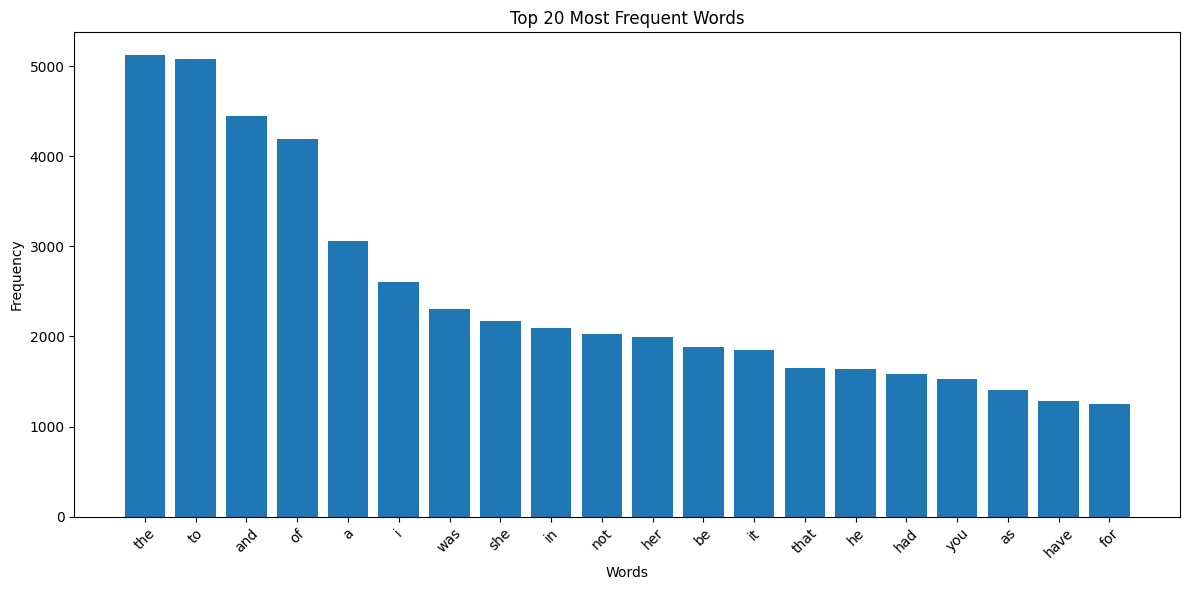

In [39]:
import matplotlib.pyplot as plt

# Get 20 most common words
top_words = word_freq.most_common(20)

# Separate words and frequencies
words_list = [word for word, count in top_words]
counts = [count for word, count in top_words]

# Create bar chart
plt.figure(figsize=(12, 6))
plt.bar(words_list, counts)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [40]:
import pandas as pd

# Test sentences
test_sentences = [
    "I am",
    "she was",
    "he is",
    "the",
    "I love emna"
]

results = []

for sentence in test_sentences:
    result = smart_text_assistant(sentence)

    results.append({
        "Input": sentence,
        "Feature": result["type"],
        "Suggestions": ", ".join(result["suggestions"])
    })

# Create DataFrame
results_df = pd.DataFrame(results)

# Display results
results_df

,Input,Feature,Suggestions
0,I am,Autocomplete,"sure, very, not, quite, afraid"
1,she was,Autocomplete,"not, a, the, to, very"
2,he is,Autocomplete,"a, not, the, so, very"
3,the,Autocomplete,"and, very, i, same, the"
4,I love emna,Autocorrect,emma


In [46]:
import matplotlib.pyplot as plt

test_words = [
    "emna",
    "hous",
    "frend",
    "beautifull",
    "womman"
]

results = []

for word in test_words:
    suggestions = autocorrect(word)

    print(word, "→", suggestions)

    results.append(
        f"{word} → {', '.join(suggestions)}"
    )



emna → ['emma']
hous → ['house', 'hours', 'houses', 'thus', 'ours']
frend → ['friend', 'friends', 'freed', 'friendly', 'befriend']
beautifull → ['beautifully', 'beautiful', 'dutiful']
womman → ['woman', 'womanly', 'command', 'women']


In [41]:
# Save the results to a CSV file

results_df.to_csv("autocomplete_autocorrect_results.csv", index=False)

print("Results saved successfully!")
print("File name: autocomplete_autocorrect_results.csv")

Results saved successfully!
File name: autocomplete_autocorrect_results.csv


In [42]:
print("=" * 60)
print("AUTOCOMPLETE AND AUTOCORRECT SYSTEM")
print("=" * 60)

print("\nDataset: NLTK Gutenberg - Emma by Jane Austen")
print("Total tokens:", len(words))
print("Total clean words:", len(clean_words))
print("Unique words:", len(word_freq))

print("\nFeatures implemented:")
print("1. Word frequency analysis")
print("2. Bigram-based autocomplete")
print("3. Sentence autocomplete")
print("4. Dictionary-based autocorrect")
print("5. Interactive text assistant")

print("\nProject completed successfully!")

AUTOCOMPLETE AND AUTOCORRECT SYSTEM

Dataset: NLTK Gutenberg - Emma by Jane Austen
Total tokens: 158167
Total clean words: 128684
Unique words: 5914

Features implemented:
1. Word frequency analysis
2. Bigram-based autocomplete
3. Sentence autocomplete
4. Dictionary-based autocorrect
5. Interactive text assistant

Project completed successfully!
